# Pipeline ML v6 — Dimensionnement et répartition des opérateurs par pôle
## Clients S et W — Random Forest avec intervalles de confiance

**Modèle : Random Forest**
- Intervalles de confiance natifs (P10 / P90) via prédictions des arbres individuels
- Robuste aux outliers — adapté à BULK_W
- `TEST_START = '2026-01-01'` — 3 ans de train (2023+2024+2025)

**Structure :**
1. Chargement des données + contraintes transport
2. Agrégation séparée S / W
3. Feature engineering avec contraintes transport
4. Walk-Forward Validation
5. Entraînement Random Forest (7 modèles)
6. Évaluation avec couverture des intervalles
7. Conversion volume → opérateurs
8. Prédiction J+1 avec fourchette min/max
9. Simulation complète de la période de test
10. Export des résultats
11. Prédiction 2026 complète avec cadrage prévisions S/W
12. Analyse du risque de sous-staffing et sur-staffing
13. Détection des valeurs aberrantes — fichier warnings
14. Export PowerBI

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.1f}'.format)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

# 8 pôles — GLOBAL séparé en GLOBAL_S et GLOBAL_W
POLES       = ['BULK_S','BULK_W','PICKING_S','PICKING_W',
               'PROMO_S','PROMO_W','GLOBAL_S','GLOBAL_W']
RANDOM_SEED = 42

# Productivités réelles (OL/heure × 7h/jour)
# Source : document Productivités OETP
HEURES_PAR_JOUR = 7
PRODUCTIVITE_HORAIRE = {
    'BULK_S'    : 26.5,
    'BULK_W'    : 26.5,
    'PICKING_S' : 157.0,
    'PICKING_W' : 157.0,
    'PROMO_S'   : 125.0,
    'PROMO_W'   : 125.0,
    'GLOBAL_S'  : 102.83,
    'GLOBAL_W'  : 102.83,
}
PRODUCTIVITE = {p: round(v * HEURES_PAR_JOUR) for p, v in PRODUCTIVITE_HORAIRE.items()}

print('Imports OK — Random Forest | 8 pôles')
print('\nProductivités journalières (OL/op/jour) :')
for p, v in PRODUCTIVITE.items():
    print(f'  {p:12s} : {PRODUCTIVITE_HORAIRE[p]:5.1f} OL/h × {HEURES_PAR_JOUR}h = {v:>5} OL/op/jour')


Imports OK — Random Forest | 8 pôles

Productivités journalières (OL/op/jour) :
  BULK_S       :  26.5 OL/h × 7h =   186 OL/op/jour
  BULK_W       :  26.5 OL/h × 7h =   186 OL/op/jour
  PICKING_S    : 157.0 OL/h × 7h =  1099 OL/op/jour
  PICKING_W    : 157.0 OL/h × 7h =  1099 OL/op/jour
  PROMO_S      : 125.0 OL/h × 7h =   875 OL/op/jour
  PROMO_W      : 125.0 OL/h × 7h =   875 OL/op/jour
  GLOBAL_S     : 102.8 OL/h × 7h =   720 OL/op/jour
  GLOBAL_W     : 102.8 OL/h × 7h =   720 OL/op/jour


## 1. Chargement des données

Les fichiers attendus sont au format :
- `DATE` : date de l'opération
- `WORKFLOW` : code de type `PREPARATION_{S|W}_{BULK|PICKING|PROMO|GLOBAL}_{Pays}`
- `QUANTITY` : volume traité

> **Adaptez la variable `DATA_FOLDER`** pour pointer vers votre dossier contenant les fichiers 2023.xlsx, 2024.xlsx, etc.

In [2]:
# ─── CONFIGURATION ───────────────────────────────────────────────────────────
DATA_FOLDER      = Path('../DATA/')
SHEET_NAME       = 'Grid Results'
TRANSPORT_FILE   = Path('../DATA/20260319 Plan de transport simplifié pour le Crunch.xlsx')
PREVISIONS_FILE  = Path('../DATA/Prévisions S_W.xlsx')
# ─────────────────────────────────────────────────────────────────────────────

def load_all_files(folder, sheet):
    files = sorted(folder.glob('20*.xlsx'))
    if not files:
        raise FileNotFoundError(f"Aucun fichier trouvé dans {folder}")
    frames = []
    for f in files:
        try:
            xls = pd.ExcelFile(f)
        except Exception as e:
            warnings.warn(f"Impossible de lire {f.name} : {e}")
            continue
        if sheet not in xls.sheet_names:
            warnings.warn(f"Fichier ignoré : {f.name} — onglet '{sheet}' absent")
            continue
        df = pd.read_excel(f, sheet_name=sheet, header=0)
        df.columns = df.columns.str.strip().str.upper()
        frames.append(df)
        print(f"  ✓ {f.name} — {len(df):,} lignes")
    raw = pd.concat(frames, ignore_index=True)
    raw['DATE'] = pd.to_datetime(raw['DATE'])
    return raw.sort_values('DATE').drop_duplicates()

# ── Données historiques ───────────────────────────────────────────────────────
print(f"Chargement depuis : {DATA_FOLDER.resolve()}")
raw = load_all_files(DATA_FOLDER, SHEET_NAME)
print(f"Total : {len(raw):,} lignes | {raw['DATE'].min().date()} → {raw['DATE'].max().date()}")

# ── Plan de transport : jours actifs par (client, type_op, jour_semaine) ──────
transport = pd.read_excel(TRANSPORT_FILE, sheet_name='Plan de transport', header=0)
transport.columns = ['CLIENT','TERRITOIRE','WORKFLOW','LUNDI','MARDI','MERCREDI','JEUDI','VENDREDI']
transport = transport.dropna(subset=['WORKFLOW'])
transport['CLIENT']    = transport['CLIENT'].ffill()
transport['TERRITOIRE']= transport['TERRITOIRE'].ffill()

DAYS_MAP = {'LUNDI':0,'MARDI':1,'MERCREDI':2,'JEUDI':3,'VENDREDI':4}
DAYS     = list(DAYS_MAP.keys())
transport['jours_list'] = transport[DAYS].apply(
    lambda r: [DAYS_MAP[d] for d in DAYS if r[d]=='X'], axis=1)

# Dict workflow → jours actifs (utilisé pour les features)
WORKFLOW_JOURS = dict(zip(transport['WORKFLOW'], transport['jours_list']))

# Nb pays actifs par (client, type_op, dow) → feature clé
records = []
for _, row in transport.iterrows():
    m = re.match(r'PREPARATION_([SW])_(BULK|PICKING|PROMO|GLOBAL)', row['WORKFLOW'])
    if not m:
        continue
    cli, top = m.group(1), m.group(2)
    for jour, dow in DAYS_MAP.items():
        records.append({'client': cli, 'type_op': top, 'dow': dow,
                        'actif': 1 if row[jour]=='X' else 0})

TRANSPORT_FEAT = (pd.DataFrame(records)
                  .groupby(['client','type_op','dow'])['actif']
                  .sum()
                  .reset_index()
                  .rename(columns={'actif':'nb_pays_actifs'}))

print(f"\nPlan de transport chargé : {len(transport)} workflows")
print(TRANSPORT_FEAT.pivot_table(index=['client','type_op'], columns='dow',
                                  values='nb_pays_actifs').to_string())

# ── Prévisions mensuelles S/W (cadrage 2026) ──────────────────────────────────
prev_raw = pd.read_excel(PREVISIONS_FILE, sheet_name='Feuil1', header=0)
prev_raw.columns = ['DATE','WORKFLOW','QUANTITY','_3','_4','_5','NOTE']
PREVISIONS_SW = (prev_raw[['DATE','WORKFLOW','QUANTITY']]
                 .dropna(subset=['WORKFLOW','QUANTITY'])
                 .assign(DATE=lambda d: pd.to_datetime(d['DATE']),
                         CLIENT=lambda d: d['WORKFLOW'].str.extract(r'PREPARATION_([SW])_')[0],
                         ZONE=lambda d: d['WORKFLOW'].str.replace(r'PREPARATION_[SW]_','',regex=True)))
print(f"\nPrévisions S/W chargées : {len(PREVISIONS_SW)} lignes")
print(f"Période : {PREVISIONS_SW['DATE'].min().date()} → {PREVISIONS_SW['DATE'].max().date()}")


Chargement depuis : C:\Users\andre\Documents\crunch\DATA
  ✓ 2023.xlsx — 13,583 lignes
  ✓ 2024.xlsx — 19,413 lignes
  ✓ 2025.xlsx — 18,341 lignes
  ✓ 2026.xlsx — 2,958 lignes
Total : 54,295 lignes | 2023-01-05 → 2026-02-27

Plan de transport chargé : 74 workflows
dow               0   1   2    3   4
client type_op                      
S      BULK     5.0 7.0 3.0  6.0 6.0
       PICKING  5.0 7.0 3.0  6.0 6.0
       PROMO    5.0 7.0 3.0  6.0 6.0
W      BULK    15.0 6.0 7.0 13.0 4.0
       PICKING 16.0 6.0 7.0 14.0 4.0
       PROMO   16.0 6.0 7.0 14.0 4.0

Prévisions S/W chargées : 165 lignes
Période : 2025-10-01 → 2026-12-01


## 2. Parsing du WORKFLOW et agrégation par pôle

In [3]:
def parse_workflow(wf):
    """Extrait (client, type_op, pays) depuis un code WORKFLOW."""
    m = re.match(r'PREPARATION_([SW])_(BULK|PICKING|GLOBAL|PROMO)(?:_(.+))?', wf)
    if m:
        return m.group(1), m.group(2), m.group(3) or 'ALL'
    return None, None, None

parsed = raw['WORKFLOW'].apply(lambda x: pd.Series(parse_workflow(x),
                                                    index=['CLIENT','TYPE_OP','PAYS']))
raw = pd.concat([raw, parsed], axis=1)

print("Clients :")
print(raw['CLIENT'].value_counts().to_dict())
print("\nTypes d'opération :")
print(raw['TYPE_OP'].value_counts().to_dict())
print(f"\nNombre de pays : {raw['PAYS'].nunique()}")


Clients :
{'W': 33108, 'S': 21187}

Types d'opération :
{'PICKING': 18706, 'BULK': 17203, 'PROMO': 16874, 'GLOBAL': 1512}

Nombre de pays : 66


In [4]:
# ── Agrégation par (DATE, CLIENT, TYPE_OP) ───────────────────────────────────
# GLOBAL_S et GLOBAL_W sont maintenant des pôles distincts (8 pôles au total)

# Tous les types d'opération séparés par client
daily_raw = (
    raw.groupby(['DATE','CLIENT','TYPE_OP'])['QUANTITY']
    .sum()
    .unstack(['CLIENT','TYPE_OP'], fill_value=0)
    .reset_index()
)
# Aplatir les colonnes multi-niveaux : (S, BULK) → BULK_S, (W, GLOBAL) → GLOBAL_W
daily_raw.columns = (['DATE'] +
    [f'{top}_{cli}' for cli, top in daily_raw.columns[1:]])
daily_raw.columns.name = None

# S'assurer que tous les pôles existent
for p in POLES:
    if p not in daily_raw.columns:
        daily_raw[p] = 0

# Nb pays actifs ce jour (global et par client)
nb_pays = raw.groupby('DATE')['PAYS'].nunique().rename('NB_PAYS')
daily   = daily_raw.merge(nb_pays, on='DATE', how='left')
for cli in ['S','W']:
    nb = raw[raw['CLIENT']==cli].groupby('DATE')['PAYS'].nunique().rename(f'NB_PAYS_{cli}')
    daily = daily.merge(nb, on='DATE', how='left')

# ── Réindexation sur calendrier continu ───────────────────────────────────────
date_range = pd.date_range(daily['DATE'].min(), daily['DATE'].max(), freq='D')
daily = daily.set_index('DATE').reindex(date_range).rename_axis('DATE').reset_index()
for col in POLES + ['NB_PAYS','NB_PAYS_S','NB_PAYS_W']:
    if col in daily.columns:
        daily[col] = daily[col].fillna(0)

daily['TOTAL']   = daily[POLES].sum(axis=1)
daily['TOTAL_S'] = daily[[p for p in POLES if p.endswith('_S')]].sum(axis=1)
daily['TOTAL_W'] = daily[[p for p in POLES if p.endswith('_W')]].sum(axis=1)
daily['IS_WEEKEND'] = (daily['DATE'].dt.dayofweek >= 5).astype(int)

print(f"Jours calendaires : {len(daily)}")
print(f"Dont weekends     : {daily['IS_WEEKEND'].sum()}")
print(f"Jours ouvrés      : {(daily['IS_WEEKEND']==0).sum()}")
print("\nStats par pôle :")
display(daily[POLES].describe().round(0))


Jours calendaires : 1150
Dont weekends     : 328
Jours ouvrés      : 822

Stats par pôle :


,BULK_S,BULK_W,PICKING_S,PICKING_W,PROMO_S,PROMO_W,GLOBAL_S,GLOBAL_W
count,1150.0,1150.0,1150.0,1150.0,1150.0,1150.0,1150.0,1150.0
mean,365.0,376.0,4717.0,6283.0,1896.0,3784.0,6978.0,10442.0
std,406.0,376.0,5205.0,6498.0,2422.0,4037.0,7612.0,10144.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,282.0,355.0,3690.0,5894.0,1246.0,3310.0,5682.0,9950.0
75%,560.0,586.0,7067.0,9826.0,2806.0,6956.0,10396.0,17310.0
max,3089.0,3070.0,31196.0,54532.0,15810.0,17787.0,40587.0,65742.0


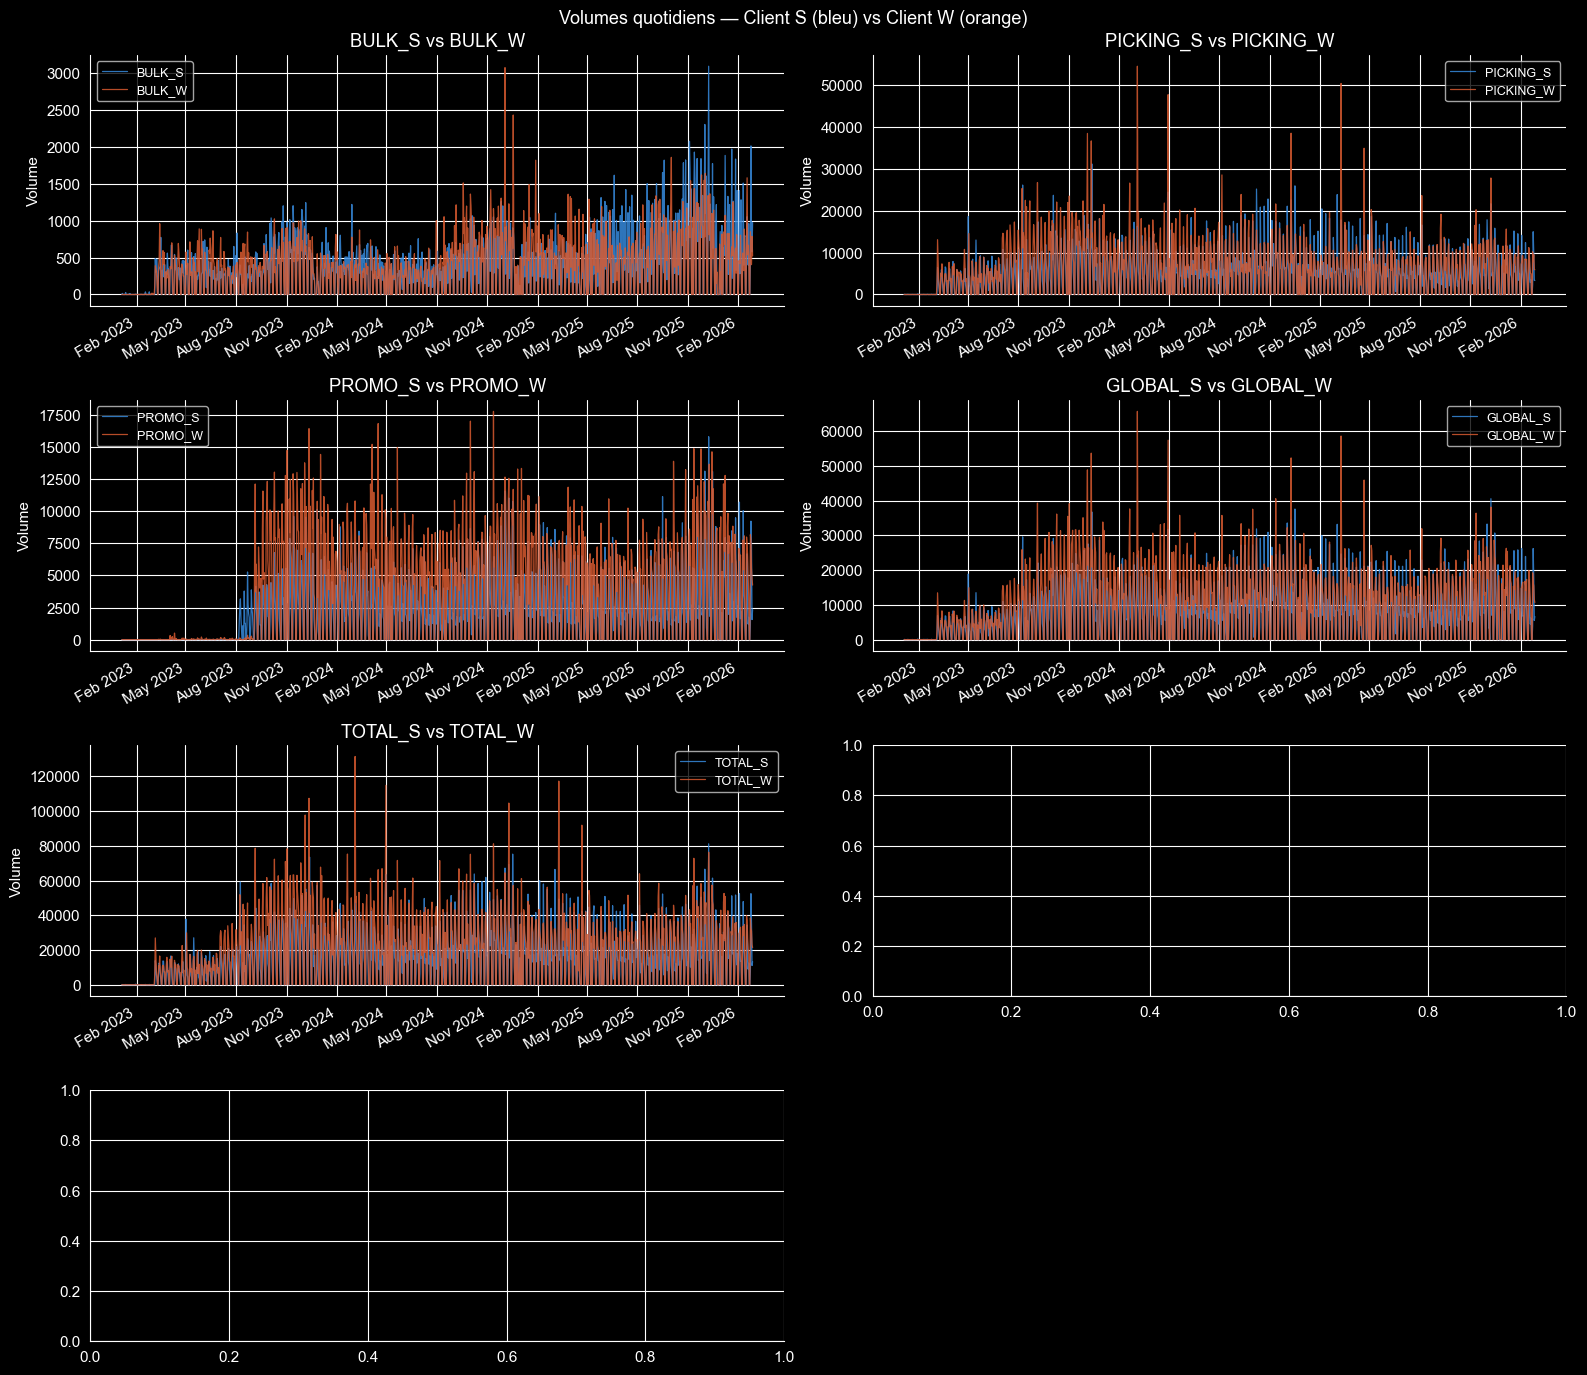

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
pairs = [('BULK_S','BULK_W'), ('PICKING_S','PICKING_W'),
         ('PROMO_S','PROMO_W'), ('GLOBAL_S','GLOBAL_W'),
         ('TOTAL_S','TOTAL_W')]
colors_s = '#378ADD'
colors_w = '#D85A30'

for ax, (pole_s, pole_w) in zip(axes.flat, pairs):
    if pole_s in daily.columns:
        ax.plot(daily['DATE'], daily[pole_s], color=colors_s, lw=0.9,
                alpha=0.85, label=f'{pole_s}')
    if pole_w in daily.columns:
        ax.plot(daily['DATE'], daily[pole_w], color=colors_w, lw=0.9,
                alpha=0.85, label=f'{pole_w}')
    ax.set_title(f'{pole_s} vs {pole_w}', fontweight='500')
    ax.set_ylabel('Volume')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=9)

axes.flat[-1].set_visible(False)
fig.suptitle('Volumes quotidiens — Client S (bleu) vs Client W (orange)',
             fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()


## 3. Feature Engineering

On construit les features **uniquement à partir d'informations connues au moment de la prédiction (J)** pour prédire J+1, afin d'éviter tout data leakage.

In [6]:
# ── Jours fériés français ────────────────────────────────────────────────────
FERIES_FR = pd.to_datetime([
    '2023-01-01','2023-04-10','2023-05-01','2023-05-08','2023-05-18','2023-05-29',
    '2023-07-14','2023-08-15','2023-11-01','2023-11-11','2023-12-25',
    '2024-01-01','2024-04-01','2024-05-01','2024-05-08','2024-05-09','2024-05-20',
    '2024-07-14','2024-08-15','2024-11-01','2024-11-11','2024-12-25',
    '2025-01-01','2025-04-21','2025-05-01','2025-05-08','2025-05-29','2025-06-09',
    '2025-07-14','2025-08-15','2025-11-01','2025-11-11','2025-12-25',
    '2026-01-01','2026-04-06','2026-05-01','2026-05-08','2026-05-14','2026-05-25',
    '2026-07-14','2026-08-15','2026-11-01','2026-11-11','2026-12-25',
])
# UK : pas de départ J-1 (donc pas de prépa J-1 → impacte W uniquement)
FERIES_UK_VEILLE = FERIES_FR  # même jours fériés UK → on bloque J-1

def get_transport_feature(client, type_op, dow, transport_feat):
    """Retourne le nb de pays actifs ce (client, type_op, jour_semaine)."""
    mask = ((transport_feat['client']  == client) &
            (transport_feat['type_op'] == type_op) &
            (transport_feat['dow']     == dow))
    rows = transport_feat[mask]
    return int(rows['nb_pays_actifs'].iloc[0]) if len(rows) else 0

def build_features(df, poles, transport_feat,
                   lags=[1,7,14,28,365], windows=[7,14,28,90]):
    out = df.copy().sort_values('DATE').reset_index(drop=True)

    # ── Features temporelles ─────────────────────────────────────────────────
    out['DOW']         = out['DATE'].dt.dayofweek
    out['WEEK']        = out['DATE'].dt.isocalendar().week.astype(int)
    out['MONTH']       = out['DATE'].dt.month
    out['QUARTER']     = out['DATE'].dt.quarter
    out['DAY_OF_YEAR'] = out['DATE'].dt.dayofyear
    out['YEAR']        = out['DATE'].dt.year
    out['IS_FERIE']    = out['DATE'].isin(FERIES_FR).astype(int)
    out['IS_VEILLE_FERIE'] = out['DATE'].apply(
        lambda d: (d + pd.Timedelta(days=1)) in FERIES_FR).astype(int)
    out['IS_WEEKEND']  = (out['DATE'].dt.dayofweek >= 5).astype(int)
    out['DOW_SIN']     = np.sin(2*np.pi*out['DOW']/7)
    out['DOW_COS']     = np.cos(2*np.pi*out['DOW']/7)
    out['MONTH_SIN']   = np.sin(2*np.pi*out['MONTH']/12)
    out['MONTH_COS']   = np.cos(2*np.pi*out['MONTH']/12)

    # ── Pics commerciaux ─────────────────────────────────────────────────────
    out['BLACK_FRIDAY'] = ((out['MONTH']==11) & (out['DATE'].dt.day>=20)).astype(int)
    out['NOEL_PEAK']    = ((out['MONTH']==12) & (out['DATE'].dt.day<=24)).astype(int)
    out['SOLDES']       = (((out['MONTH']==1)) |
                           ((out['MONTH']==6) & (out['DATE'].dt.day>=24))).astype(int)

    # ── Transitions entre collections ────────────────────────────────────────
    out['TRANS_W2S'] = (out['MONTH'].isin([3,4])).astype(int)
    out['TRANS_S2W'] = (out['MONTH'].isin([8,9])).astype(int)
    out['WEEKS_TO_TRANS'] = out['DATE'].apply(lambda d: min(
        abs((d - pd.Timestamp(f'{d.year}-04-01')).days),
        abs((d - pd.Timestamp(f'{d.year}-09-01')).days)) // 7)

    # ── Contraintes transport S/W par jour de semaine ─────────────────────────
    # Pour chaque (client, type_op) : nb de pays actifs CE jour → signal de charge
    for cli in ['S','W']:
        for top in ['BULK','PICKING','PROMO']:
            col = f'TRANSPORT_{cli}_{top}_ACTIF'
            out[col] = out['DOW'].apply(
                lambda d: get_transport_feature(cli, top, d, transport_feat))

    # Règle UK (client W) : J-1 avant férié UK → pas de prépa W_UK
    out['UK_VEILLE_FERIE'] = out['DATE'].apply(
        lambda d: int((d + pd.Timedelta(days=1)) in FERIES_UK_VEILLE)).astype(int)

    # ── Lags, rolling et features dérivées — par pôle ────────────────────────
    for pole in poles:
        for lag in lags:
            out[f'{pole}_LAG{lag}'] = out[pole].shift(lag)
        for w in windows:
            out[f'{pole}_ROLL{w}'] = out[pole].shift(1).rolling(w, min_periods=1).mean()
        # Tendance long terme — correction biais sur-prédiction
        out[f'{pole}_TREND90'] = out[pole].shift(1).rolling(90, min_periods=14).mean()
        # Momentum semaine/semaine
        roll7  = out[pole].shift(1).rolling(7,  min_periods=1).mean()
        roll14 = out[pole].shift(8).rolling(7,  min_periods=1).mean()
        out[f'{pole}_WOW'] = (roll7 / (roll14 + 1e-6)).clip(0, 5)

    # ── Features BULK et GLOBAL spécifiques ─────────────────────────────────────
    for cli in ['S','W']:
        pick = f'PICKING_{cli}'
        if pick in poles:
            out[f'PICKING_{cli}_LAG1_for_BULK'] = out[pick].shift(1)
        bulk = f'BULK_{cli}'
        if bulk in poles:
            out[f'BULK_{cli}_RATIO_TOTAL'] = (
                out[bulk].shift(1) / (out['TOTAL'].shift(1) + 1e-6)).clip(0,1)
            out[f'BULK_{cli}_STD14'] = (
                out[bulk].shift(1).rolling(14, min_periods=3).std().fillna(0))

    # ── NB_PAYS et TOTAL ─────────────────────────────────────────────────────
    for cli in ['S','W','']:
        suffix = f'_{cli}' if cli else ''
        col = f'NB_PAYS{suffix}'
        if col in out.columns:
            out[f'NB_PAYS{suffix}_LAG1']  = out[col].shift(1)
            out[f'NB_PAYS{suffix}_ROLL7'] = out[col].shift(1).rolling(7, min_periods=1).mean()

    for lag in [1,7]:
        out[f'TOTAL_LAG{lag}']   = out['TOTAL'].shift(lag)
        out[f'TOTAL_S_LAG{lag}'] = out['TOTAL_S'].shift(lag)
        out[f'TOTAL_W_LAG{lag}'] = out['TOTAL_W'].shift(lag)

    # ── Cibles J+1 ───────────────────────────────────────────────────────────
    for pole in poles:
        out[f'TARGET_{pole}'] = out[pole].shift(-1)

    return out

features_df = build_features(daily, POLES, TRANSPORT_FEAT)

FEATURE_COLS = [c for c in features_df.columns
                if c not in (['DATE'] + POLES +
                              ['TOTAL','TOTAL_S','TOTAL_W','NB_PAYS','NB_PAYS_S','NB_PAYS_W','IS_WEEKEND'])
                and not c.startswith('TARGET_')]

print(f"Features construites : {len(FEATURE_COLS)}")


Features construites : 131


## 4. Walk-Forward Validation

On simule les conditions réelles : le modèle ne voit jamais le futur lors de l'évaluation.

```
Train ─────────────────────┤ Test │
                           ↓
Train ──────────────────────────┤ Test │
                                ↓
        ... expansion progressive ...
```

In [7]:
def walk_forward_split(df, train_start, test_start, step_days=1):
    """Expanding window — retourne des DATES pour éviter les désalignements d'index."""
    active = df[
        (df['IS_WEEKEND'] == 0) &
        (~df['DATE'].isin(FERIES_FR))
    ].copy().reset_index(drop=True)

    dates   = active['DATE'].values
    t_start = pd.Timestamp(test_start)
    t_end   = dates.max()
    current = t_start

    while current <= t_end:
        tr_mask = dates < current
        te_mask = dates == current
        if tr_mask.sum() > 50 and te_mask.sum() > 0:
            yield (active.loc[tr_mask, 'DATE'].values,
                   active.loc[te_mask, 'DATE'].values)
        current += pd.Timedelta(days=step_days)


TRAIN_START = '2023-01-01'
TEST_START  = '2026-01-01'   # 3 ans de train (2023+2024+2025), test sur 2026
STEP_DAYS   = 1

splits = list(walk_forward_split(
    features_df.dropna(subset=[f'TARGET_{POLES[0]}']),
    TRAIN_START, TEST_START, STEP_DAYS))
print(f"Splits walk-forward (jours ouvrés, 3 ans de train) : {len(splits)}")
if splits:
    print(f"  Premier split — train : {len(splits[0][0])} jours")
    print(f"  Dernière date de test : {pd.Timestamp(max(splits[-1][1])).date()}")


Splits walk-forward (jours ouvrés, 3 ans de train) : 40
  Premier split — train : 751 jours
  Dernière date de test : 2026-02-26


## 5. Entraînement Random Forest avec intervalles de confiance

In [8]:
def tune_rf(df, pole, feature_cols, n_iter=40):
    """
    RandomizedSearchCV sur RandomForestRegressor.
    Plus rapide qu'Optuna pour RF car l'espace est plus restreint.
    """
    target_col = f'TARGET_{pole}'
    data = df[
        (df['IS_WEEKEND'] == 0) &
        (~df['DATE'].isin(FERIES_FR))
    ].dropna(subset=[target_col] + feature_cols).copy()

    cut    = max(30, int(len(data) * 0.8))
    X_tr, y_tr = data.iloc[:cut][feature_cols], data.iloc[:cut][target_col]

    param_dist = {
        'n_estimators'     : [200, 300, 500, 800],
        'max_depth'        : [None, 6, 10, 15, 20],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf' : [1, 2, 4, 8],
        'max_features'     : ['sqrt', 'log2', 0.5, 0.7],
        'bootstrap'        : [True],
    }

    rf = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)
    search = RandomizedSearchCV(rf, param_dist, n_iter=n_iter,
                                cv=3, scoring='neg_mean_absolute_error',
                                random_state=RANDOM_SEED, n_jobs=-1)
    search.fit(X_tr, y_tr)
    mae_val = -search.best_score_
    print(f"  {pole} — MAE val: {mae_val:.0f} | params: {search.best_params_}")
    return search.best_params_


def predict_quantile_rf(model, X, quantile=0.9):
    """
    Prédit les intervalles de confiance depuis les arbres individuels du RF.
    Retourne (prédiction moyenne, borne basse q10, borne haute q90).
    """
    # Prédictions de chaque arbre individuellement
    tree_preds = np.array([tree.predict(X) for tree in model.estimators_])
    # tree_preds shape: (n_estimators, n_samples)
    pred_mean = np.maximum(0, tree_preds.mean(axis=0))
    pred_low  = np.maximum(0, np.percentile(tree_preds, (1-quantile)*100, axis=0))
    pred_high = np.maximum(0, np.percentile(tree_preds, quantile*100,     axis=0))
    return pred_mean, pred_low, pred_high


def train_evaluate_pole_rf(df, pole, feature_cols, splits, rf_params):
    """Walk-forward Random Forest — retourne prédictions + intervalles."""
    target_col = f'TARGET_{pole}'
    data = df.dropna(subset=[target_col] + feature_cols).copy()

    oof_mean, oof_low, oof_high = [], [], []
    oof_actual, oof_dates = [], []

    for tr_dates, te_dates in splits:
        X_tr = data[data['DATE'].isin(tr_dates)][feature_cols]
        y_tr = data[data['DATE'].isin(tr_dates)][target_col]
        X_te = data[data['DATE'].isin(te_dates)][feature_cols]
        y_te = data[data['DATE'].isin(te_dates)][target_col]
        if len(X_tr) < 30 or len(X_te) == 0:
            continue

        model = RandomForestRegressor(**rf_params, random_state=RANDOM_SEED, n_jobs=-1)
        model.fit(X_tr, y_tr)

        mean, low, high = predict_quantile_rf(model, X_te)
        oof_mean.extend(mean)
        oof_low.extend(low)
        oof_high.extend(high)
        oof_actual.extend(y_te.values)
        oof_dates.extend(te_dates)

    # Modèle final sur toutes les données
    final = RandomForestRegressor(**rf_params, random_state=RANDOM_SEED, n_jobs=-1)
    final.fit(data[feature_cols], data[target_col])

    df_oos = pd.DataFrame({
        'date'  : oof_dates,
        'actual': oof_actual,
        'pred'  : oof_mean,
        'low'   : oof_low,
        'high'  : oof_high,
    }).sort_values('date').reset_index(drop=True)

    return final, df_oos


# ── Tuning + entraînement ─────────────────────────────────────────────────────
print("Tuning Random Forest (40 itérations par pôle)...")
BEST_PARAMS_RF = {}
for pole in POLES:
    print(f"  → {pole}...", end=' ', flush=True)
    BEST_PARAMS_RF[pole] = tune_rf(features_df, pole, FEATURE_COLS)

print("\nEntraînement walk-forward (7 pôles)...")
models  = {}
results = {}
for pole in POLES:
    print(f"  → {pole}...", end=' ')
    m, res = train_evaluate_pole_rf(features_df, pole, FEATURE_COLS,
                                    splits, BEST_PARAMS_RF[pole])
    models[pole]  = m
    results[pole] = res
    print(f"{len(res)} points OOS")

print("\nTerminé.")


Tuning Random Forest (40 itérations par pôle)...
  → BULK_S... 

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

## 6. Évaluation avec intervalles de confiance

In [ ]:
def evaluate(res):
    y_true, y_pred = res['actual'], res['pred']
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    mask = y_true > 0
    mape = (np.abs((y_true[mask]-y_pred[mask])/y_true[mask]).mean()*100) if mask.sum() else np.nan
    # Couverture des intervalles : % de valeurs réelles dans [low, high]
    coverage = ((res['actual'] >= res['low']) & (res['actual'] <= res['high'])).mean() * 100
    return {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape, 'Couverture IC (%)': coverage}

metrics_df = pd.DataFrame({p: evaluate(results[p]) for p in POLES}).T.round(2)
print("── Métriques Random Forest ──")
display(metrics_df)

for cli in ['S','W']:
    poles_cli = [p for p in POLES if p.endswith(f'_{cli}')]
    mets = metrics_df.loc[poles_cli]
    print(f"\nClient {cli} — R² moyen : {mets['R²'].mean():.2f} "
          f"| MAPE moyen : {mets['MAPE (%)'].mean():.1f}%"
          f"| Couverture IC : {mets['Couverture IC (%)'].mean():.1f}%")


In [ ]:
colors_map = {
    'BULK_S'    :'#0C447C', 'BULK_W'    :'#D85A30',
    'PICKING_S' :'#185FA5', 'PICKING_W' :'#993C1D',
    'PROMO_S'   :'#3B8BD4', 'PROMO_W'   :'#F0997B',
    'GLOBAL_S'  :'#3B6D11', 'GLOBAL_W'  :'#85B7EB',
}

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
for ax, pole in zip(axes.flat, POLES):
    res   = results[pole]
    color = colors_map.get(pole, '#888780')
    if res.empty:
        ax.set_visible(False); continue

    ax.plot(res['date'], res['actual'], color='#B4B2A9', lw=1.0, alpha=0.8, label='Réel')
    ax.plot(res['date'], res['pred'],   color=color,     lw=1.2,             label='RF prédit')
    ax.fill_between(res['date'], res['low'], res['high'],
                    alpha=0.15, color=color, label='IC 80%')

    m = evaluate(res)
    ax.set_title(f"{pole}  |  R²={m['R²']:.2f}  MAPE={m['MAPE (%)']:.1f}%  "
                 f"IC={m['Couverture IC (%)']:.0f}%", fontweight='500')
    ax.set_ylabel('Volume'); ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Random Forest — Prédictions + IC 80% (8 pôles)', fontsize=13, fontweight='500')
plt.tight_layout(); plt.show()


In [ ]:
# ── Heatmap MAPE % par pôle et par mois ──────────────────────────────────────
err_rows = []
for pole in POLES:
    res = results[pole].copy()
    res['month'] = pd.to_datetime(res['date']).dt.month
    res['mape']  = (res['actual'] - res['pred']).abs() / (res['actual'] + 1e-6) * 100
    for m, g in res.groupby('month'):
        err_rows.append({'pole': pole, 'month': m, 'mape': g['mape'].mean()})

err_df = pd.DataFrame(err_rows).pivot(index='pole', columns='month', values='mape')
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(err_df, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=0, vmax=40, linewidths=0.5, ax=ax, cbar_kws={'label': 'MAPE %'})
ax.set_title('MAPE % par pôle-client et par mois', fontweight='500')
ax.set_xlabel('Mois'); ax.set_ylabel('')
plt.tight_layout(); plt.show()


In [ ]:
# ── Importance des features (pôle PICKING_W comme exemple) ───────────────────
pole_plot = 'PICKING_W'
imp = pd.Series(models[pole_plot].feature_importances_,
                index=FEATURE_COLS).sort_values(ascending=False)
top20 = imp.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color='#378ADD', alpha=0.8)
ax.set_xlabel('Importance (impureté moyenne)')
ax.set_title(f'Top 20 features — Pôle {pole_plot}', fontweight='500')
plt.tight_layout(); plt.show()


## 7. Prédiction J+1 avec intervalles de confiance

In [ ]:
# ── Productivités réelles (déjà définies dans les imports, rappel ici) ────────
# Source : document Productivités OETP
# Formule : OL/heure × 7 heures/jour
print("Productivités utilisées pour la conversion volume → opérateurs :")
for p, v in PRODUCTIVITE.items():
    print(f"  {p:12s} : {PRODUCTIVITE_HORAIRE[p]:5.1f} OL/h × {HEURES_PAR_JOUR}h = {v:>5} OL/op/jour")

def volume_to_operators(volumes, productivite, min_ops=1):
    """Convertit un dict {pole: volume} en {pole: nb_operateurs}."""
    return {p: max(min_ops, int(np.ceil(v / productivite[p])))
            for p, v in volumes.items()}

# Vérification : exemple sur un jour type
print("\nExemple de conversion pour un jour type :")
exemple = {'BULK_S':500,'BULK_W':400,'PICKING_S':15000,'PICKING_W':12000,
           'PROMO_S':8000,'PROMO_W':6000,'GLOBAL_S':3000,'GLOBAL_W':2500}
ops = volume_to_operators(exemple, PRODUCTIVITE)
print(f"{'Pôle':12s} {'Volume':>10} {'Productivité':>14} {'Opérateurs':>12}")
print("-" * 52)
for p in POLES:
    print(f"{p:12s} {exemple[p]:>10,} {PRODUCTIVITE[p]:>14,} {ops[p]:>12}")
print(f"{'TOTAL':12s} {sum(exemple.values()):>10,} {'':>14} {sum(ops.values()):>12}")


## 9. Simulation complète de la période de test

Rejoue l'ensemble du walk-forward et calcule les opérateurs prédits vs réels,
avec la fourchette min/max issue des intervalles de confiance RF.


In [ ]:
def replay_walk_forward(features_df, results, poles, productivite):
    """Reconstruit le tableau réel vs prédit avec intervalles par pôle."""
    rows = []
    for pole in poles:
        for _, r in results[pole].iterrows():
            prod = productivite[pole]
            rows.append({
                'date'     : r['date'],
                'pole'     : pole,
                'client'   : pole.split('_')[-1] if '_' in pole else 'S+W',
                'vol_reel' : r['actual'],
                'vol_pred' : r['pred'],
                'vol_low'  : r['low'],
                'vol_high' : r['high'],
                'ops_reel' : max(1, int(np.ceil(r['actual'] / prod))),
                'ops_pred' : max(1, int(np.ceil(r['pred']   / prod))),
                'ops_low'  : max(1, int(np.ceil(r['low']    / prod))),
                'ops_high' : max(1, int(np.ceil(r['high']   / prod))),
            })
    df = pd.DataFrame(rows)
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values(['date','pole'])

replay = replay_walk_forward(features_df, results, POLES, PRODUCTIVITE)
print(f"Jours simulés : {replay['date'].nunique()}")
display(replay.head(14))


In [ ]:
# ── Total opérateurs S vs W avec intervalles de confiance ─────────────────────
daily_ops   = replay.groupby('date')[['ops_reel','ops_pred','ops_low','ops_high']].sum()
daily_ops_s = replay[replay['client']=='S'].groupby('date')[['ops_reel','ops_pred','ops_low','ops_high']].sum()
daily_ops_w = replay[replay['client'].isin(['W','S+W'])].groupby('date')[['ops_reel','ops_pred','ops_low','ops_high']].sum()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for ax, dop, label, color in zip(
        axes,
        [daily_ops, daily_ops_s, daily_ops_w],
        ['Total entrepôt', 'Client S', 'Client W + GLOBAL'],
        ['#534AB7', '#185FA5', '#D85A30']):
    ax.fill_between(dop.index, dop['ops_low'], dop['ops_high'],
                    alpha=0.15, color=color, label='IC 80%')
    ax.plot(dop.index, dop['ops_reel'], color='#B4B2A9', lw=1.0, label='Réel', alpha=0.8)
    ax.plot(dop.index, dop['ops_pred'], color=color,     lw=1.2, label='Prédit')
    ax.set_title(label, fontweight='500')
    ax.set_ylabel("Nb opérateurs")
    ax.legend(fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.suptitle('Opérateurs prédits vs réels + IC 80% — Walk-Forward',
             fontsize=13, fontweight='500')
plt.tight_layout(); plt.show()

ecart = (daily_ops['ops_pred'] - daily_ops['ops_reel']).abs().mean()
couv  = ((daily_ops['ops_reel'] >= daily_ops['ops_low']) &
         (daily_ops['ops_reel'] <= daily_ops['ops_high'])).mean() * 100
print(f"Écart moyen absolu total : {ecart:.1f} opérateur(s)/jour")
print(f"Couverture IC 80%        : {couv:.1f}% des jours réels dans la fourchette")


## 10. Export des résultats

In [ ]:
OUTPUT_FILE = 'resultats_previsions_rf.xlsx'

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    metrics_df.to_excel(writer, sheet_name='Métriques')
    for pole in POLES:
        results[pole].to_excel(writer, sheet_name=f'OOS_{pole[:10]}', index=False)
    replay.to_excel(writer, sheet_name='Replay_opérateurs', index=False)
    daily_ops.to_excel(writer, sheet_name='Total_jour')
    daily_ops_s.to_excel(writer, sheet_name='Total_jour_S')
    daily_ops_w.to_excel(writer, sheet_name='Total_jour_W')

print(f"Exporté : {OUTPUT_FILE}")


## 11. Prédiction 2026 complète avec cadrage prévisions S/W

In [ ]:
def get_monthly_cadrage(previsions_sw, client, annee, mois):
    mask = ((previsions_sw['CLIENT'] == client) &
            (previsions_sw['DATE'].dt.year  == annee) &
            (previsions_sw['DATE'].dt.month == mois))
    return float(previsions_sw[mask]['QUANTITY'].sum())


def predict_full_year(year, features_df, models, poles, feature_cols,
                      productivite, feries, previsions_sw, transport_feat):
    """
    Prédictions journalières Random Forest pour toute l'année `year`.
    - Weekends et fériés exclus
    - Intervalles de confiance P10/P90 par pôle
    - Cadrage mensuel sur les prévisions S/W
    """
    date_range = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')
    rows = []

    for date in date_range:
        if date.dayofweek >= 5 or date in feries:
            continue
        row = features_df[features_df['DATE'] == date]
        if row.empty:
            continue
        X = row[feature_cols]

        vol_pred = {}
        vol_low  = {}
        vol_high = {}
        for pole in poles:
            mean, low, high = predict_quantile_rf(models[pole], X)
            raw_pred = float(mean[0])
            raw_low  = float(low[0])
            raw_high = float(high[0])
            # Contrainte transport : 0 pays actifs → 0 volume
            if '_' in pole:
                cli_p = pole.split('_')[1]
                top_p = pole.split('_')[0]
                if get_transport_feature(cli_p, top_p, date.dayofweek, transport_feat) == 0:
                    raw_pred = raw_low = raw_high = 0.0
            vol_pred[pole] = round(raw_pred)
            vol_low[pole]  = round(raw_low)
            vol_high[pole] = round(raw_high)

        ops      = volume_to_operators(vol_pred, productivite)
        ops_low  = volume_to_operators(vol_low,  productivite)
        ops_high = volume_to_operators(vol_high, productivite)

        rows.append({
            'date'        : date,
            'jour_semaine': date.strftime('%A'),
            'semaine'     : date.isocalendar().week,
            **{f'vol_{p}'     : vol_pred[p] for p in poles},
            **{f'vol_low_{p}' : vol_low[p]  for p in poles},
            **{f'vol_high_{p}': vol_high[p] for p in poles},
            **{f'ops_{p}'     : ops[p]      for p in poles},
            **{f'ops_low_{p}' : ops_low[p]  for p in poles},
            **{f'ops_high_{p}': ops_high[p] for p in poles},
            'vol_total'   : sum(vol_pred.values()),
            'ops_total'   : sum(ops.values()),
            'ops_total_low' : sum(ops_low.values()),
            'ops_total_high': sum(ops_high.values()),
            'ops_S'       : sum(ops[p] for p in poles if p.endswith('_S')),
            'ops_W'       : sum(ops[p] for p in poles if p.endswith('_W') ),
        })

    df_pred = pd.DataFrame(rows)
    df_pred['date'] = pd.to_datetime(df_pred['date'])

    # Cadrage mensuel par client (sur la valeur centrale uniquement)
    # Cadrage mensuel par client (sur la valeur centrale uniquement)
    for cli in ['S','W']:
        poles_cli = [p for p in poles if p.endswith(f'_{cli}')]
        vol_cols  = [f'vol_{p}' for p in poles_cli]
        for mois in range(1, 13):
            mask      = df_pred['date'].dt.month == mois
            vol_prevu = get_monthly_cadrage(previsions_sw, cli, year, mois)
            if vol_prevu == 0:
                continue
            vol_predit = df_pred.loc[mask, vol_cols].values.sum()
            if vol_predit == 0:
                continue
            ratio = vol_prevu / vol_predit
            for col in vol_cols + [f'vol_low_{p}' for p in poles_cli] + [f'vol_high_{p}' for p in poles_cli]:
                df_pred.loc[mask, col] = (df_pred.loc[mask, col] * ratio).round(0)
            for p in poles_cli:
                prod = productivite[p]
                for suffix in ['', '_low', '_high']:
                    vol_col = f'vol{suffix}_{p}'
                    op_col  = f'ops{suffix}_{p}'
                    df_pred.loc[mask, op_col] = (
                        df_pred.loc[mask, vol_col].apply(
                            lambda v: max(1, int(np.ceil(v / prod)))))
        df_pred['ops_total']      = sum(df_pred[f'ops_{p}']     for p in poles)
        df_pred['ops_total_low']  = sum(df_pred[f'ops_low_{p}'] for p in poles)
        df_pred['ops_total_high'] = sum(df_pred[f'ops_high_{p}'] for p in poles)
        df_pred['ops_S']          = sum(df_pred[f'ops_{p}']     for p in poles if p.endswith('_S'))
        df_pred['ops_W']          = sum(df_pred[f'ops_{p}']     for p in poles if p.endswith('_W'))
    return df_pred


ANNEE_PREDICTION = 2026
df_pred_2026 = predict_full_year(
    ANNEE_PREDICTION, features_df, models, POLES, FEATURE_COLS,
    PRODUCTIVITE, FERIES_FR, PREVISIONS_SW, TRANSPORT_FEAT)

print(f"Jours ouvrés prédits en {ANNEE_PREDICTION} : {len(df_pred_2026)}")
display(df_pred_2026[['date','jour_semaine',
                       'ops_total','ops_total_low','ops_total_high',
                       'ops_S','ops_W']].head(10))


In [ ]:
# ── Visualisation 2026 avec intervalles de confiance ─────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Client S
poles_s = [p for p in POLES if p.endswith('_S')]
for ax, (poles_cli, label, color) in zip(axes, [
        (poles_s, 'Client S', '#185FA5'),
        ([p for p in POLES if p.endswith('_W')], 'Client W', '#D85A30')]):

    ops_central = sum(df_pred_2026[f'ops_{p}'] for p in poles_cli)
    ops_lo      = sum(df_pred_2026[f'ops_low_{p}']  for p in poles_cli)
    ops_hi      = sum(df_pred_2026[f'ops_high_{p}'] for p in poles_cli)

    ax.fill_between(df_pred_2026['date'], ops_lo, ops_hi,
                    alpha=0.20, color=color, label='IC 80%')
    ax.plot(df_pred_2026['date'], ops_central, color=color, lw=1.2, label='Central')
    ax.set_title(f'{label} — opérateurs prédits {ANNEE_PREDICTION}', fontweight='500')
    ax.set_ylabel("Nb opérateurs"); ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'Prédiction {ANNEE_PREDICTION} avec intervalles de confiance 80% — Random Forest',
             fontsize=13, fontweight='500')
plt.tight_layout(); plt.show()

# Résumé mensuel
df_pred_2026['mois'] = df_pred_2026['date'].dt.month
monthly = df_pred_2026.groupby('mois').agg(
    jours_ouvres    =('date','count'),
    ops_S_moy       =('ops_S','mean'),
    ops_W_moy       =('ops_W','mean'),
    ops_total_moy   =('ops_total','mean'),
    ops_total_min   =('ops_total_low','mean'),
    ops_total_max   =('ops_total_high','mean'),
).round(1)
print(f"\nRésumé mensuel {ANNEE_PREDICTION} (avec fourchette min/max) :")
display(monthly)


## 12. Analyse du risque de sous-staffing et sur-staffing

Pour chaque journée, on quantifie deux risques opérationnels :

- **Sous-staffing** : volume réel > volume prédit → manque d'opérateurs → risque de retard (*KO*)
- **Sur-staffing** : volume réel < volume prédit → excès d'opérateurs → coût inutile

**Méthodologie :**
- Les **intervalles de confiance P10/P90** du Random Forest mesurent l'incertitude intrinsèque
- `risque_sous_staff = ops_high − ops_central` — opérateurs supplémentaires qui pourraient manquer
- `risque_sur_staff  = ops_central − ops_low`  — opérateurs excédentaires possibles
- **Niveau de risque** : FAIBLE (amplitude IC < 15 %) · MODÉRÉ (15–30 %) · ÉLEVÉ (> 30 %)

**Structure :**
1. Analyse rétrospective sur la période de test (replay walk-forward)
2. Analyse prospective 2026 (prévisionnel)
3. Export Excel dédié `staffing_risk_2026.xlsx`

In [ ]:
# ── Fonctions d'analyse du risque + analyse rétrospective ────────────────────
def classify_risk(amplitude_ratio):
    """Classifie le niveau de risque selon l'amplitude relative de l'IC P10/P90."""
    if amplitude_ratio < 0.15:
        return 'FAIBLE'
    elif amplitude_ratio < 0.30:
        return 'MODÉRÉ'
    else:
        return 'ÉLEVÉ'


def analyze_staffing_risk(replay_df, poles):
    """
    Analyse le risque réalisé sur la période de test.
    Compare ops_pred vs ops_reel et calcule l'exposition IC par pôle et par jour.
    - SOUS-STAFF : on a sous-prédit → manque d'opérateurs
    - SUR-STAFF  : on a sur-prédit  → excès d'opérateurs
    """
    rows = []
    for _, r in replay_df.iterrows():
        ecart     = r['ops_pred'] - r['ops_reel']
        ecart_abs = abs(ecart)
        ecart_pct = ecart_abs / (r['ops_reel'] + 1e-6) * 100

        if ecart < -0.5:
            statut = 'SOUS-STAFF'
        elif ecart > 0.5:
            statut = 'SUR-STAFF'
        else:
            statut = 'OK'

        amplitude       = r['ops_high'] - r['ops_low']
        amplitude_ratio = amplitude / (r['ops_pred'] + 1e-6)

        rows.append({
            'date'              : r['date'],
            'pole'              : r['pole'],
            'client'            : r['client'],
            'ops_reel'          : r['ops_reel'],
            'ops_pred'          : r['ops_pred'],
            'ops_low'           : r['ops_low'],
            'ops_high'          : r['ops_high'],
            'ecart_ops'         : round(ecart, 1),
            'ecart_abs'         : round(ecart_abs, 1),
            'ecart_pct'         : round(ecart_pct, 1),
            'statut_reel'       : statut,
            'risque_sous_staff' : max(0, r['ops_high'] - r['ops_pred']),
            'risque_sur_staff'  : max(0, r['ops_pred'] - r['ops_low']),
            'amplitude_ic'      : amplitude,
            'amplitude_ratio'   : round(amplitude_ratio, 3),
            'niveau_risque'     : classify_risk(amplitude_ratio),
        })
    return pd.DataFrame(rows)


risk_historique = analyze_staffing_risk(replay, POLES)
print(f"Période analysée : {risk_historique['date'].min().date()} → {risk_historique['date'].max().date()}")
print(f"Observations (jours × pôles) : {len(risk_historique)}")
print(f"\nRépartition des statuts réalisés :")
display(risk_historique['statut_reel'].value_counts().to_frame())

# ── Résumé par pôle ───────────────────────────────────────────────────────────
resume_risque = risk_historique.groupby('pole').agg(
    jours_total     = ('date',              'nunique'),
    pct_sous_staff  = ('statut_reel',       lambda x: round((x == 'SOUS-STAFF').mean()*100, 1)),
    pct_sur_staff   = ('statut_reel',       lambda x: round((x == 'SUR-STAFF').mean()*100, 1)),
    pct_ok          = ('statut_reel',       lambda x: round((x == 'OK').mean()*100, 1)),
    ecart_moy_abs   = ('ecart_abs',         'mean'),
    ecart_max       = ('ecart_abs',         'max'),
    risque_sous_moy = ('risque_sous_staff', 'mean'),
    risque_sur_moy  = ('risque_sur_staff',  'mean'),
    niveau_dominant = ('niveau_risque',     lambda x: x.mode()[0] if len(x) else 'N/A'),
).round(1)
print("\n── Résumé du risque par pôle (période de test) ──")
display(resume_risque)

In [ ]:
# ── Visualisation du risque historique ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Taux de sous/sur-staffing réalisé par pôle
ax = axes[0, 0]
x     = np.arange(len(POLES))
width = 0.35
ax.bar(x - width/2, resume_risque['pct_sous_staff'], width,
       label='Sous-staffing', color='#D85A30', alpha=0.8)
ax.bar(x + width/2, resume_risque['pct_sur_staff'], width,
       label='Sur-staffing', color='#378ADD', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(POLES, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% des jours')
ax.set_title('Taux de sous/sur-staffing réalisé par pôle', fontweight='500')
ax.legend()

# 2. Distribution des écarts (opérateurs)
ax = axes[0, 1]
colors_statut = {'SOUS-STAFF': '#D85A30', 'SUR-STAFF': '#378ADD', 'OK': '#70A860'}
for statut, color in colors_statut.items():
    data = risk_historique[risk_historique['statut_reel'] == statut]['ecart_ops']
    ax.hist(data, bins=20, alpha=0.6, color=color, label=statut)
ax.axvline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('Écart (ops_pred − ops_réel)')
ax.set_ylabel('Nombre de jours × pôles')
ax.set_title('Distribution des écarts de staffing', fontweight='500')
ax.legend()

# 3. Niveau de risque IC par pôle (empilé)
ax = axes[1, 0]
risk_niveau     = risk_historique.groupby(['pole','niveau_risque']).size().unstack(fill_value=0)
risk_niveau_pct = risk_niveau.div(risk_niveau.sum(axis=1), axis=0) * 100
colors_niv      = {'FAIBLE': '#70A860', 'MODÉRÉ': '#FAC775', 'ÉLEVÉ': '#D85A30'}
bottom = np.zeros(len(risk_niveau_pct))
for niv, color in colors_niv.items():
    if niv in risk_niveau_pct.columns:
        vals = risk_niveau_pct[niv].values
        ax.bar(risk_niveau_pct.index, vals, bottom=bottom, label=niv, color=color, alpha=0.85)
        bottom += vals
ax.set_xticklabels(risk_niveau_pct.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% des jours')
ax.set_title('Niveau de risque IC par pôle (période de test)', fontweight='500')
ax.legend()

# 4. Exposition au risque dans le temps
ax = axes[1, 1]
total_risk_hist = risk_historique.groupby('date')[['risque_sous_staff','risque_sur_staff']].sum()
ax.fill_between(total_risk_hist.index,  total_risk_hist['risque_sous_staff'],
                alpha=0.55, color='#D85A30', label='Risque sous-staffing')
ax.fill_between(total_risk_hist.index, -total_risk_hist['risque_sur_staff'],
                alpha=0.55, color='#378ADD', label='Risque sur-staffing')
ax.axhline(0, color='black', lw=1.0)
ax.set_ylabel('Opérateurs à risque')
ax.set_title('Exposition au risque dans le temps (entrepôt)', fontweight='500')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Analyse du risque réalisé — Sous-staffing / Sur-staffing (période de test)',
             fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

In [ ]:
# ── Analyse du risque prospectif — 2026 ───────────────────────────────────────
def analyze_risk_2026(df_pred, poles):
    """
    Quantifie le risque de sous/sur-staffing pour chaque jour × pôle en 2026.
    Basé sur l'amplitude de l'IC P10/P90 du Random Forest.
    """
    rows = []
    for _, r in df_pred.iterrows():
        for pole in poles:
            ops_c = r[f'ops_{pole}']
            ops_l = r[f'ops_low_{pole}']
            ops_h = r[f'ops_high_{pole}']

            amplitude       = ops_h - ops_l
            amplitude_ratio = amplitude / (ops_c + 1e-6)
            risque_sous     = max(0, ops_h - ops_c)   # ops supplémentaires possibles
            risque_sur      = max(0, ops_c - ops_l)   # ops économisables possibles

            if risque_sous > risque_sur * 1.5:
                tendance = 'SOUS-STAFF probable'
            elif risque_sur > risque_sous * 1.5:
                tendance = 'SUR-STAFF probable'
            else:
                tendance = 'NEUTRE'

            rows.append({
                'date'              : r['date'],
                'jour_semaine'      : r['jour_semaine'],
                'mois'              : r['date'].month,
                'semaine'           : r['semaine'],
                'pole'              : pole,
                'client'            : pole.split('_')[-1] if '_' in pole else 'S+W',
                'ops_central'       : ops_c,
                'ops_min'           : ops_l,
                'ops_max'           : ops_h,
                'risque_sous_staff' : risque_sous,
                'risque_sur_staff'  : risque_sur,
                'amplitude_ic'      : amplitude,
                'amplitude_ratio'   : round(amplitude_ratio, 3),
                'niveau_risque'     : classify_risk(amplitude_ratio),
                'tendance'          : tendance,
            })
    return pd.DataFrame(rows)


risk_2026 = analyze_risk_2026(df_pred_2026, POLES)
print(f"Jours × pôles analysés en 2026 : {len(risk_2026)}")
print(f"\nRépartition des niveaux de risque :")
display(risk_2026['niveau_risque'].value_counts().to_frame())
print(f"\nTendances :")
display(risk_2026['tendance'].value_counts().to_frame())

In [ ]:
import matplotlib.patches as mpatches

# ── Agrégation journalière toutes pôles ───────────────────────────────────────
daily_risk_2026 = risk_2026.groupby('date').agg(
    risque_sous = ('risque_sous_staff', 'sum'),
    risque_sur  = ('risque_sur_staff',  'sum'),
    amplitude   = ('amplitude_ic',      'sum'),
    ops_central = ('ops_central',       'sum'),
).reset_index()
daily_risk_2026['amplitude_ratio_total'] = (
    daily_risk_2026['amplitude'] / (daily_risk_2026['ops_central'] + 1e-6))
daily_risk_2026['niveau'] = daily_risk_2026['amplitude_ratio_total'].apply(classify_risk)

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# 1. Exposition au risque
ax = axes[0]
ax.fill_between(daily_risk_2026['date'],  daily_risk_2026['risque_sous'],
                alpha=0.65, color='#D85A30', label='Risque sous-staffing (ops manquants possibles)')
ax.fill_between(daily_risk_2026['date'], -daily_risk_2026['risque_sur'],
                alpha=0.65, color='#378ADD', label='Risque sur-staffing (ops excédentaires possibles)')
ax.axhline(0, color='black', lw=1.0)
ax.set_ylabel('Opérateurs à risque')
ax.set_title('Exposition totale au risque (entrepôt complet)', fontweight='500')
ax.legend(fontsize=9)

# 2. Code couleur niveau de risque
ax = axes[1]
colors_level = {'FAIBLE': '#70A860', 'MODÉRÉ': '#FAC775', 'ÉLEVÉ': '#D85A30'}
for _, row in daily_risk_2026.iterrows():
    ax.axvline(row['date'], color=colors_level.get(row['niveau'], 'grey'), alpha=0.6, lw=2)
patches_leg = [mpatches.Patch(color=c, label=l) for l, c in colors_level.items()]
ax.legend(handles=patches_leg, fontsize=9)
ax.set_title('Niveau de risque quotidien (amplitude IC 80%)', fontweight='500')
ax.set_yticks([])

# 3. Staffing central avec fourchette
ax = axes[2]
ops_min_total = daily_risk_2026['ops_central'] - daily_risk_2026['risque_sur']
ops_max_total = daily_risk_2026['ops_central'] + daily_risk_2026['risque_sous']
ax.fill_between(daily_risk_2026['date'], ops_min_total, ops_max_total,
                alpha=0.20, color='#534AB7', label='Fourchette de risque IC 80%')
ax.plot(daily_risk_2026['date'], daily_risk_2026['ops_central'],
        color='#534AB7', lw=1.2, label='Staffing central prédit')
ax.set_ylabel('Nb opérateurs (total entrepôt)')
ax.set_title('Prédiction staffing 2026 avec zones de risque', fontweight='500')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Analyse du risque prospectif 2026 — Sous-staffing / Sur-staffing',
             fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

# ── Résumé mensuel du risque 2026 ─────────────────────────────────────────────
monthly_risk = risk_2026.groupby('mois').agg(
    jours_ouvres    = ('date',              'nunique'),
    pct_faible      = ('niveau_risque',     lambda x: round((x == 'FAIBLE').mean()*100, 1)),
    pct_modere      = ('niveau_risque',     lambda x: round((x == 'MODÉRÉ').mean()*100, 1)),
    pct_eleve       = ('niveau_risque',     lambda x: round((x == 'ÉLEVÉ').mean()*100, 1)),
    risque_sous_moy = ('risque_sous_staff', 'mean'),
    risque_sur_moy  = ('risque_sur_staff',  'mean'),
    tendance_dom    = ('tendance',          lambda x: x.mode()[0] if len(x) else 'N/A'),
).round(1)
print("Résumé mensuel du risque 2026 :")
display(monthly_risk)

In [ ]:
# ── Export Excel — Analyse des risques ───────────────────────────────────────
RISK_FILE = 'staffing_risk_2026.xlsx'

jours_critiques = risk_2026[risk_2026['niveau_risque'] == 'ÉLEVÉ'].copy()

colors_sev = {
    'ÉLEVÉ'              : PatternFill('solid', fgColor='F7C1C1'),
    'MODÉRÉ'             : PatternFill('solid', fgColor='FAC775'),
    'FAIBLE'             : PatternFill('solid', fgColor='C0DD97'),
    'SOUS-STAFF'         : PatternFill('solid', fgColor='F7C1C1'),
    'SUR-STAFF'          : PatternFill('solid', fgColor='C6D9F1'),
    'OK'                 : PatternFill('solid', fgColor='C0DD97'),
    'SOUS-STAFF probable': PatternFill('solid', fgColor='FAC775'),
    'SUR-STAFF probable' : PatternFill('solid', fgColor='C6D9F1'),
    'NEUTRE'             : PatternFill('solid', fgColor='EFEFEF'),
}

def style_risk_sheet(ws, risk_col):
    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal='center')
    for i in range(1, ws.max_column + 1):
        ws.column_dimensions[get_column_letter(i)].width = 16
    col_names = [c.value for c in ws[1]]
    if risk_col in col_names:
        idx = col_names.index(risk_col)
        for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
            val = row[idx].value
            fc  = colors_sev.get(val)
            if fc:
                for cell in row:
                    cell.fill = fc

with pd.ExcelWriter(RISK_FILE, engine='openpyxl') as writer:
    risk_historique.to_excel(writer, sheet_name='Risque_historique', index=False)
    risk_2026.to_excel(writer, sheet_name='Risque_2026', index=False)
    monthly_risk.to_excel(writer, sheet_name='Résumé_mensuel_risque')
    resume_risque.to_excel(writer, sheet_name='Résumé_pôle_historique')
    jours_critiques[['date','jour_semaine','mois','semaine','pole','client',
                      'ops_central','ops_min','ops_max',
                      'risque_sous_staff','risque_sur_staff',
                      'niveau_risque','tendance']].to_excel(
        writer, sheet_name='Jours_critiques_2026', index=False)

    style_risk_sheet(writer.sheets['Risque_historique'],      'statut_reel')
    style_risk_sheet(writer.sheets['Risque_2026'],             'niveau_risque')
    style_risk_sheet(writer.sheets['Jours_critiques_2026'],    'niveau_risque')
    for cell in writer.sheets['Résumé_mensuel_risque'][1]:
        cell.font = Font(bold=True)
    for cell in writer.sheets['Résumé_pôle_historique'][1]:
        cell.font = Font(bold=True)

print(f"Exporté : {RISK_FILE}")
print(f"  Onglets :")
print(f"    Risque_historique      — {len(risk_historique):,} lignes (période de test)")
print(f"    Risque_2026            — {len(risk_2026):,} lignes (prévisionnel)")
print(f"    Résumé_mensuel_risque  — agrégation mensuelle")
print(f"    Résumé_pôle_historique — stats par pôle")
print(f"    Jours_critiques_2026   — {len(jours_critiques):,} lignes (risque ÉLEVÉ uniquement)")
print(f"\n  Jours à risque ÉLEVÉ : {jours_critiques['date'].nunique()}")
print(f"  Répartition mensuelle des jours critiques :")
display(jours_critiques.groupby('mois')['date'].nunique().rename('Jours critiques').to_frame())

## 13. Détection des valeurs aberrantes — fichier warnings

In [ ]:
def detect_anomalies(df_pred, features_df, poles, z_thresh=2.5, iqr_mult=2.0):
    """
    Détecte les valeurs aberrantes dans les prédictions.
    Méthodes : Z-score et IQR sur l'historique (jours ouvrés non fériés).
    Sévérité : CRITIQUE (|Z|>4), ATTENTION (|Z|>2.5), INFO (IQR seulement).
    """
    warn_list = []
    for pole in poles:
        vol_col = f'vol_{pole}'
        if vol_col not in df_pred.columns:
            continue
        hist = features_df[
            (features_df['IS_WEEKEND']==0) &
            (~features_df['DATE'].isin(FERIES_FR)) &
            (features_df[pole] > 0)
        ][pole]
        mu, sigma = hist.mean(), hist.std()
        q1, q3 = hist.quantile(0.25), hist.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - iqr_mult*iqr, q3 + iqr_mult*iqr

        for _, row in df_pred.iterrows():
            val = row[vol_col]
            z   = (val - mu) / (sigma + 1e-6)
            flags = []
            if abs(z) > z_thresh:
                flags.append(f'Z-score={z:.1f} (seuil ±{z_thresh})')
            if val > hi:
                flags.append(f'Au-dessus IQR ({val:.0f} > {hi:.0f})')
            if 0 < val < lo:
                flags.append(f'En-dessous IQR ({val:.0f} < {lo:.0f})')
            if not flags:
                continue
            sev = ('CRITIQUE' if abs(z) > 4.0 else
                   'ATTENTION' if abs(z) > z_thresh else 'INFO')
            warn_list.append({
                'Date'         : row['date'].strftime('%Y-%m-%d'),
                'Jour'         : row['jour_semaine'],
                'Pôle'         : pole,
                'Client'       : pole.split('_')[-1] if '_' in pole else 'S+W',
                'Volume prédit': int(val),
                'Moyenne hist.': round(mu, 0),
                'Z-score'      : round(z, 2),
                'Sévérité'     : sev,
                'Raison'       : ' | '.join(flags),
            })

    df_w = pd.DataFrame(warn_list)
    if not df_w.empty:
        df_w = df_w.sort_values(['Sévérité','Date'])
    return df_w


df_warnings = detect_anomalies(df_pred_2026, features_df, POLES)
print(f"Valeurs aberrantes détectées : {len(df_warnings)}")
if not df_warnings.empty:
    print(df_warnings['Sévérité'].value_counts().to_string())
    display(df_warnings.head(20))

# ── Export Excel warnings ─────────────────────────────────────────────────────
WARNINGS_FILE = 'warnings_predictions_2026.xlsx'
fill = {'CRITIQUE': PatternFill('solid', fgColor='F7C1C1'),
        'ATTENTION': PatternFill('solid', fgColor='FAC775'),
        'INFO'     : PatternFill('solid', fgColor='C0DD97')}

with pd.ExcelWriter(WARNINGS_FILE, engine='openpyxl') as writer:
    # Onglet Warnings
    if df_warnings.empty:
        pd.DataFrame([{'Message': 'Aucune valeur aberrante'}]).to_excel(
            writer, sheet_name='Warnings', index=False)
    else:
        df_warnings.to_excel(writer, sheet_name='Warnings', index=False)
        ws = writer.sheets['Warnings']
        sev_idx = list(df_warnings.columns).index('Sévérité')
        for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
            sev  = row[sev_idx].value
            fill_cell = fill.get(sev)
            for cell in row:
                if fill_cell: cell.fill = fill_cell
            row[sev_idx].font = Font(bold=True)
        for i, col in enumerate(df_warnings.columns, 1):
            ws.column_dimensions[get_column_letter(i)].width = max(14, len(col)+4)
        for cell in ws[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(horizontal='center')

    # Onglet Prédictions 2026
    df_pred_2026.to_excel(writer, sheet_name='Predictions_2026', index=False)
    ws2 = writer.sheets['Predictions_2026']
    for i, col in enumerate(df_pred_2026.columns, 1):
        ws2.column_dimensions[get_column_letter(i)].width = 14
    for cell in ws2[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal='center')

    # Onglet Résumé mensuel
    monthly.to_excel(writer, sheet_name='Résumé_mensuel')

    # Onglet Résumé par client
    resume_client = df_pred_2026.groupby('mois')[['ops_S','ops_W','ops_total']].mean().round(1)
    resume_client.to_excel(writer, sheet_name='Résumé_S_vs_W')

print(f"\nFichier exporté : {WARNINGS_FILE}")
print(f"  Onglets : Warnings | Predictions_2026 | Résumé_mensuel | Résumé_S_vs_W")


## 14. Export PowerBI — alimentation automatique du dossier partagé

In [ ]:
from datetime import datetime

# ─── CONFIGURATION ────────────────────────────────────────────────────────────
POWERBI_FOLDER = Path(r'C:\\Users\\Rodri\\Desktop\\UTT\\P26\\crunch\\DATA\\Result')
PREFIX = 'CRUNCH'
# ─────────────────────────────────────────────────────────────────────────────

def export_for_powerbi(df_pred_2026, results, metrics_df, daily, replay,
                       poles, productivite, folder, prefix):
    """
    Exporte les CSV pour PowerBI Desktop.
    Inclut les intervalles de confiance RF dans toutes les tables.
    """
    folder.mkdir(parents=True, exist_ok=True)
    ts      = datetime.now().strftime('%Y-%m-%d %H:%M')
    exports = {}

    # 1. Prédiction J+1 avec fourchette
    last_date = features_df['DATE'].max()
    j1_rows   = []
    for pole in poles:
        row_feat = features_df[features_df['DATE'] == last_date]
        if row_feat.empty: continue
        X = row_feat[FEATURE_COLS]
        mean, low, high = predict_quantile_rf(models[pole], X)
        ops_c = max(1, int(np.ceil(mean[0] / productivite[pole])))
        ops_l = max(1, int(np.ceil(low[0]  / productivite[pole])))
        ops_h = max(1, int(np.ceil(high[0] / productivite[pole])))
        j1_rows.append({
            'date_prediction' : last_date.strftime('%Y-%m-%d'),
            'date_j1'         : (last_date + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
            'pole'            : pole,
            'client'          : pole.split('_')[-1] if '_' in pole else 'S+W',
            'type_operation'  : pole.split('_')[0]  if '_' in pole else 'GLOBAL',
            'volume_predit'   : round(mean[0]),
            'nb_operateurs'   : ops_c,
            'ops_min_p10'     : ops_l,
            'ops_max_p90'     : ops_h,
            'horodatage'      : ts,
        })
    exports['predictions_j1'] = pd.DataFrame(j1_rows)

    # 2. Prévisions 2026 avec intervalles
    df_2026_pbi = df_pred_2026.copy()
    df_2026_pbi['date']       = df_2026_pbi['date'].dt.strftime('%Y-%m-%d')
    df_2026_pbi['horodatage'] = ts
    exports['previsions_2026'] = df_2026_pbi

    # 3. Résumé mensuel
    exports['previsions_2026_mens'] = monthly.reset_index().assign(horodatage=ts)

    # 4. Historique OOS avec intervalles
    oos_rows = []
    for pole in poles:
        res = results[pole].copy()
        res['pole']           = pole
        res['client']         = pole.split('_')[-1] if '_' in pole else 'S+W'
        res['type_operation'] = pole.split('_')[0]  if '_' in pole else 'GLOBAL'
        res['erreur_abs']     = (res['actual'] - res['pred']).abs()
        res['erreur_pct']     = (res['erreur_abs'] / (res['actual'] + 1e-6) * 100).round(1)
        res['dans_ic']        = ((res['actual'] >= res['low']) &
                                  (res['actual'] <= res['high'])).astype(int)
        res['date']           = pd.to_datetime(res['date']).dt.strftime('%Y-%m-%d')
        res['horodatage']     = ts
        oos_rows.append(res)
    exports['historique_oos'] = pd.concat(oos_rows, ignore_index=True)

    # 5. Métriques
    df_met = metrics_df.copy().reset_index().rename(columns={'index':'pole'})
    df_met['client']         = df_met['pole'].apply(lambda p: p.split('_')[-1] if '_' in p else 'S+W')
    df_met['type_operation'] = df_met['pole'].apply(lambda p: p.split('_')[0]  if '_' in p else 'GLOBAL')
    df_met['horodatage']     = ts
    exports['metriques_modeles'] = df_met

    # 6. Opérateurs réel vs prédit avec fourchette
    df_ops = replay.copy()
    df_ops['date']       = pd.to_datetime(df_ops['date']).dt.strftime('%Y-%m-%d')
    df_ops['horodatage'] = ts
    exports['operateurs_jour'] = df_ops

    # Écriture CSV
    print(f"Export PowerBI → {folder}")
    for name, df_exp in exports.items():
        path = folder / f'{prefix}_{name}.csv'
        df_exp.to_csv(path, index=False, encoding='utf-8-sig', sep=';')
        print(f"  ✓ {path.name} — {len(df_exp):,} lignes")

    # Métadonnées
    meta = pd.DataFrame([{
        'derniere_maj'   : ts,
        'modele'         : 'Random Forest',
        'nb_poles'       : len(poles),
        'date_min_oos'   : exports['historique_oos']['date'].min(),
        'date_max_oos'   : exports['historique_oos']['date'].max(),
        'nb_jours_2026'  : len(df_pred_2026),
        'couverture_ic'  : f"{exports['historique_oos']['dans_ic'].mean()*100:.1f}%",
        'nb_warnings'    : len(df_warnings) if 'df_warnings' in dir() else 'N/A',
    }])
    meta.to_csv(folder / f'{PREFIX}_metadata.csv', index=False, encoding='utf-8-sig', sep=';')
    print(f"  ✓ {PREFIX}_metadata.csv")


try:
    export_for_powerbi(df_pred_2026, results, metrics_df, daily, replay,
                       POLES, PRODUCTIVITE, POWERBI_FOLDER, PREFIX)
    print(f"\n{'='*55}\n  Export terminé → {POWERBI_FOLDER}\n{'='*55}")
except Exception as e:
    print(f"\n⚠ Export échoué : {e}")
    print(f"  Vérifiez que POWERBI_FOLDER est accessible : {POWERBI_FOLDER}")
